## 1. Imports and helper functions


In [53]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error
import xgboost as xgb

import torch
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, Baseline, QuantileLoss
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

## 2- Load Dataset

In [54]:
df = pd.read_csv("fobhav_noisy.csv")


In [55]:
print("Dataset shape:", df.shape)
print(df.head(3))

Dataset shape: (57600000, 16)
  INSTRUMENT     SYMBOL    EXPIRY_DT  STRIKE_PR OPTION_TYP      OPEN  \
0     FUTIDX  BANKNIFTY  24-Sep-2020        0.0         XX  24900.05   
1     FUTIDX  BANKNIFTY  29-Oct-2020        0.0         XX  24937.55   
2     FUTIDX  BANKNIFTY  26-Nov-2020        0.0         XX  24989.95   

       HIGH       LOW    CLOSE  SETTLE_PR  CONTRACTS  VAL_INLAKH   OPEN_INT  \
0  25270.00  23371.00  23743.0    23743.0   504222.0  3051593.27  1432850.0   
1  25315.90  23391.90  23770.1    23770.1    10630.0    64526.57    91375.0   
2  25280.75  23437.15  23766.2    23766.2     1171.0     7088.68    14400.0   

   CHG_IN_OI    TIMESTAMP  Column_15  
0   -54500.0  31-AUG-2020        NaN  
1    19325.0  31-AUG-2020        NaN  
2     8400.0  31-AUG-2020        NaN  


## 3- Preprocessing

In [56]:
df.columns = [c.strip().upper() for c in df.columns] 

required_columns = [
    "INSTRUMENT", "SYMBOL", "EXPIRY_DT", "STRIKE_PR", "OPTION_TYP",
    "OPEN", "HIGH", "LOW", "CLOSE", "SETTLE_PR",
    "CONTRACTS", "VAL_INLAKH", "OPEN_INT", "CHG_IN_OI", "TIMESTAMP"
]


In [57]:
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError("Missing required columns: {}".format(missing))


In [58]:

df = df[df['INSTRUMENT'].astype(str).str.upper() == 'OPTIDX'].copy()
df = df[df['SYMBOL'].astype(str).str.upper().isin(['BANKNIFTY', 'NIFTY'])].copy()
df = df[df['OPTION_TYP'].isin(['CE', 'PE'])].copy()


In [59]:
df.sample(10)

,INSTRUMENT,SYMBOL,EXPIRY_DT,STRIKE_PR,OPTION_TYP,OPEN,HIGH,LOW,CLOSE,SETTLE_PR,CONTRACTS,VAL_INLAKH,OPEN_INT,CHG_IN_OI,TIMESTAMP,COLUMN_15
48014031,OPTIDX,NIFTY,27-Aug-2015,7100.000000,CE,1443.0,1578.0,1440.4,11022.673667,-13733.277651,1047.0,2260.33,-5.192397e+07,23775.0,22-JUL-2015,NaN
24521393,OPTIDX,BANKNIFTY,26-Apr-2018,28300.000000,PE,0.0,0.0,0.0,956.550000,2654.050000,0.0,0.00,0.000000e+00,0.0,15-FEB-2018,NaN
20805033,OPTIDX,NIFTY,26-Dec-2019,8600.000000,PE,0.0,0.0,0.0,113.550000,7.150000,0.0,0.00,8.460000e+04,0.0,29-JUN-2018,NaN
13260498,OPTIDX,BANKNIFTY,18-Apr-2019,25500.000000,PE,0.0,0.0,0.0,79.600000,0.050000,0.0,0.00,0.000000e+00,0.0,27-MAR-2019,NaN
19862082,OPTIDX,NIFTY,24-Jun-2021,7100.000000,PE,0.0,0.0,0.0,95.900000,0.050000,0.0,0.00,0.000000e+00,0.0,02-AUG-2018,NaN
32819455,OPTIDX,NIFTY,30-Dec-2021,9600.000000,PE,0.0,0.0,0.0,624.100000,68.850000,0.0,0.00,0.000000e+00,0.0,15-MAY-2017,NaN
49028390,OPTIDX,BANKNIFTY,25-Jun-2015,-69053.924916,CE,0.0,0.0,0.0,1095.300000,643.200000,0.0,0.00,1.500000e+02,0.0,05-JUN-2015_UNK,NaN
26403699,OPTIDX,NIFTY,27-Dec-2018,7600.000000,PE,0.0,0.0,0.0,30.000000,0.850000,0.0,0.00,1.932750e+05,0.0,13-DEC-2017,NaN
54317300,OPTIDX,NIFTY,26-Mar-2015,8000.000000,CE,0.0,0.0,0.0,143.750000,522.750000,0.0,0.00,0.000000e+00,0.0,28-AUG-2014,NaN
40109298,OPTIDX,NIFTY,28-Jul-2016,6600.000000,CE,0.0,0.0,0.0,1373.800000,1948.650000,0.0,0.00,0.000000e+00,0.0,22-JUL-2016,NaN


In [60]:

df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], errors='coerce')
df['EXPIRY_DT'] = pd.to_datetime(df['EXPIRY_DT'], errors='coerce')


In [61]:

df = df.dropna(subset=['TIMESTAMP', 'EXPIRY_DT', 'STRIKE_PR', 'OPTION_TYP', 'OPEN_INT', 'CHG_IN_OI', 'CLOSE', 'CONTRACTS'])

numeric_cols = ['STRIKE_PR', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'SETTLE_PR', 'CONTRACTS', 'VAL_INLAKH', 'OPEN_INT', 'CHG_IN_OI']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=numeric_cols).reset_index(drop=True)

print('After preprocessing shape:', df.shape)
df.sample(10)

After preprocessing shape: (4435363, 16)


,INSTRUMENT,SYMBOL,EXPIRY_DT,STRIKE_PR,OPTION_TYP,OPEN,HIGH,LOW,CLOSE,SETTLE_PR,CONTRACTS,VAL_INLAKH,OPEN_INT,CHG_IN_OI,TIMESTAMP,COLUMN_15
660819,OPTIDX,NIFTY,2020-03-05,11950.0,PE,0.0,0.000000,0.0,69.600000,376.00,0.0,0.00,0.000000e+00,0.000000e+00,2020-02-01,NaN
3138633,optidx,NIFTY,2017-06-29,8500.0,CE,0.0,0.000000,0.0,9217.798686,928.40,0.0,0.00,-4.187668e+07,0.000000e+00,2016-09-22,NaN
3603364,OPTIDX,NIFTY,2017-12-28,5200.0,PE,0.0,0.000000,0.0,9.400000,3.35,0.0,0.00,0.000000e+00,0.000000e+00,2015-11-16,NaN
484102,OPTIDX,NIFTY,2020-04-23,7000.0,PE,0.0,0.000000,0.0,125.850000,136.10,0.0,0.00,0.000000e+00,0.000000e+00,2020-03-26,NaN
4313880,OPTIDX,NIFTY,2016-06-30,6100.0,CE,0.0,0.000000,0.0,1918.900000,2519.75,0.0,0.00,1.835500e+05,0.000000e+00,2014-06-18,NaN
2249183,OPTIDX,NIFTY,2018-09-27,7600.0,CE,0.0,0.000000,0.0,2634.250000,3273.65,0.0,0.00,0.000000e+00,0.000000e+00,2018-02-12,NaN
4043022,OPTIDX,NIFTY,2018-12-27,4300.0,PE,0.0,0.000000,0.0,14.250000,5.65,0.0,0.00,-5.404468e+07,-4.415401e+06,2015-01-08,NaN
281938,OPTIDX,NIFTY,2020-05-28,10400.0,PE,1401.7,1457.550000,1329.4,1351.650000,1351.65,6.0,53.04,3.450000e+03,-1.500000e+02,2020-05-20,NaN
1272071,OPTIDX,BANKNIFTY,2019-08-08,31900.0,CE,0.0,0.000000,0.0,1047.750000,907.40,0.0,0.00,0.000000e+00,0.000000e+00,2019-06-12,NaN
2942551,OPTIDX,NIFTY,2019-12-26,8000.0,CE,0.0,-13231.152826,0.0,1414.000000,1976.30,0.0,0.00,1.650000e+03,0.000000e+00,2017-01-13,NaN


## 4- Separate call and put aggregates by timestamp

In [63]:
df['PRICE'] = df['CLOSE'].fillna(df['SETTLE_PR'])

df.sample(5)


,INSTRUMENT,SYMBOL,EXPIRY_DT,STRIKE_PR,OPTION_TYP,OPEN,HIGH,LOW,CLOSE,SETTLE_PR,CONTRACTS,VAL_INLAKH,OPEN_INT,CHG_IN_OI,TIMESTAMP,COLUMN_15,PRICE
231013,OPTIDX,BANKNIFTY,2020-07-30,15600.0,CE,0.0,0.0,0.0,3414.50,4943.450000,0.0,0.0,0.0,0.0,2020-06-04,NaN,3414.50
2773723,OPTIDX,NIFTY,2020-12-31,7600.0,PE,0.0,0.0,0.0,98.70,-14743.322396,0.0,0.0,0.0,0.0,2017-04-25,NaN,98.70
2275485,OPTIDX,NIFTY,2020-12-31,9700.0,CE,0.0,0.0,0.0,1890.00,3188.150000,0.0,0.0,24000.0,0.0,2018-01-30,NaN,1890.00
425746,OPTIDX,BANKNIFTY,2020-04-16,17600.0,CE,0.0,0.0,0.0,3520.80,2527.050000,0.0,0.0,0.0,0.0,2020-04-09,NaN,3520.80
3634449,OPTIDX,NIFTY,2019-06-27,5300.0,PE,0.0,0.0,0.0,10.85,15.600000,0.0,0.0,0.0,0.0,2015-10-23,NaN,10.85


In [64]:
df["SYMBOL"] = df["SYMBOL"].str.upper()

In [65]:
df["SYMBOL"].unique

<bound method Series.unique of 0          BANKNIFTY
1          BANKNIFTY
2          BANKNIFTY
3          BANKNIFTY
4          BANKNIFTY
             ...    
4435358        NIFTY
4435359        NIFTY
4435360        NIFTY
4435361        NIFTY
4435362        NIFTY
Name: SYMBOL, Length: 4435363, dtype: str>

In [66]:

agg = df.groupby(['TIMESTAMP', 'SYMBOL', 'OPTION_TYP']).agg(
    total_open_int=('OPEN_INT', 'sum'),
    total_contracts=('CONTRACTS', 'sum'),
    avg_price=('PRICE', 'mean'),
    avg_chg_oi=('CHG_IN_OI', 'mean')
).reset_index()
agg.sample(10)

,TIMESTAMP,SYMBOL,OPTION_TYP,total_open_int,total_contracts,avg_price,avg_chg_oi
16474,2108-08-10,NIFTY,CE,0.000000e+00,0.000000,353.400000,0.000000
11054,2041-05-09,BANKNIFTY,PE,1.035000e+04,1759.000000,9.950000,2875.000000
8043,2017-11-21,NIFTY,CE,1.492720e+08,56754.540467,1765.285353,45195.966202
14924,2105-10-16,NIFTY,CE,-5.566451e+07,0.000000,11679.153885,0.000000
5502,2015-06-23,BANKNIFTY,PE,1.426835e+08,552445.895553,569.825422,-124994.024470
3893,2002-04-13,NIFTY,CE,0.000000e+00,0.000000,14236.329443,0.000000
12022,2061-06-09,BANKNIFTY,PE,0.000000e+00,0.000000,263.600000,0.000000
2685,219-04-26,NIFTY,CE,2.767500e+04,-231933.993998,1078.825000,10837.500000
1062,216-08-29,BANKNIFTY,PE,0.000000e+00,0.000000,235.500000,0.000000
4496,2014-06-30,BANKNIFTY,CE,-1.111352e+06,6020.155121,1284.181871,35362.201933


In [67]:
agg.shape

(17896, 7)

In [68]:
agg.value_counts("TIMESTAMP")

TIMESTAMP
214-03-13     4
214-04-21     4
214-05-13     4
214-07-30     4
215-03-04     4
             ..
2200-02-05    1
2200-07-13    1
2200-07-23    1
2200-07-29    1
2200-08-04    1
Name: count, Length: 6422, dtype: int64

In [69]:

agg_pivot = agg.pivot_table(
    index=['TIMESTAMP', 'SYMBOL'],
    columns='OPTION_TYP',
    values=['total_open_int', 'total_contracts', 'avg_price', 'avg_chg_oi'],
    fill_value=0
).reset_index()
agg_pivot.columns = ['_'.join(col).strip('_') for col in agg_pivot.columns.values] 

agg_pivot.sample(10)
print(agg_pivot.shape)

(10827, 10)


In [70]:
for col in ['total_open_int_CE', 'total_open_int_PE', 'total_contracts_CE', 'total_contracts_PE', 'avg_price_CE', 'avg_price_PE', 'avg_chg_oi_CE', 'avg_chg_oi_PE']:
    if col not in agg_pivot.columns:
        agg_pivot[col] = 0.0

agg_pivot = agg_pivot.sort_values(['TIMESTAMP', 'SYMBOL']).reset_index(drop=True)
print('Aggregated shape:', agg_pivot.shape)

agg_pivot.head(10)


Aggregated shape: (10827, 10)


,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE
0,214-03-12,NIFTY,0.0,0.000000e+00,1524.300000,698.775000,0.000000,0.000000,0.0,0.000000e+00
1,214-03-13,BANKNIFTY,0.0,0.000000e+00,1138.600000,16395.402710,0.000000,0.000000,0.0,0.000000e+00
2,214-03-13,NIFTY,0.0,0.000000e+00,1464.066667,0.050000,-254760.625284,0.000000,53000.0,0.000000e+00
3,214-03-14,NIFTY,0.0,0.000000e+00,0.000000,1066.650000,0.000000,231966.656939,0.0,0.000000e+00
4,214-03-18,NIFTY,0.0,3.610000e+04,0.000000,184.150000,0.000000,1510.000000,0.0,1.453500e+05
5,214-03-19,NIFTY,0.0,1.190247e+06,0.000000,314.200000,0.000000,0.000000,0.0,-5.097979e+07
6,214-03-20,NIFTY,0.0,-5.000000e+01,1935.575000,127.466667,193288.282278,3.000000,0.0,5.245000e+04
7,214-03-21,NIFTY,0.0,0.000000e+00,2293.150000,0.000000,302032.141402,0.000000,0.0,0.000000e+00
8,214-03-22,NIFTY,0.0,0.000000e+00,0.000000,113.825000,0.000000,0.000000,0.0,0.000000e+00
9,214-03-24,BANKNIFTY,0.0,0.000000e+00,1794.850000,1462.900000,0.000000,0.000000,0.0,0.000000e+00


## 5. Feature engineering
Create PCR, price dynamics, OI signals, and label generation.

In [71]:
# Compute PCR and derived features
agg_pivot['PCR'] = agg_pivot['total_open_int_PE'] / agg_pivot['total_open_int_CE'].replace(0, np.nan)
agg_pivot['PCR'] = agg_pivot['PCR'].fillna(0).replace([np.inf, -np.inf], 0)
agg_pivot.sample(5)


,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR
966,217-03-28,NIFTY,0.000000,0.000000,2486.675000,43.600000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
4706,2017-11-06,NIFTY,27842.647726,-16358.635399,1815.114414,464.148833,-1.057120e+06,4.161140e+05,3.382973e+08,2.497005e+08,0.738110
10168,2109-03-14,NIFTY,0.000000,0.000000,881.650000,3343.704693,0.000000e+00,0.000000e+00,-3.488322e+07,7.470163e+07,-2.141477
6879,2061-04-25,NIFTY,0.000000,0.000000,0.000000,844.525000,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e+03,0.000000
5668,2019-08-13,NIFTY,13078.631967,-4934.689939,1636.608314,480.328216,5.827034e+06,1.476198e+06,1.656650e+08,5.054351e+08,3.050946


In [72]:
agg_pivot["PCR"].dtype

dtype('float64')

In [73]:
# Use the average of CE and PE price as a proxy for market price at the timestamp
agg_pivot['PRICE'] = agg_pivot[['avg_price_CE', 'avg_price_PE']].mean(axis=1)

agg_pivot.sample(10)


,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR,PRICE
9609,2107-11-03,NIFTY,3.031807e+06,0.000000e+00,2741.850000,258.350000,0.000000,0.000000e+00,0.000000e+00,5.103877e+07,0.000000,1500.100000
6892,2061-05-09,BANKNIFTY,0.000000e+00,0.000000e+00,0.000000,865.900000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,432.950000
3413,2015-06-15,BANKNIFTY,6.467755e+04,1.024866e+05,547.938475,388.127789,-434141.755196,5.889814e+05,2.283871e+07,1.720933e+08,7.535161,468.033132
9939,2108-08-17,NIFTY,0.000000e+00,0.000000e+00,0.000000,658.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,329.000000
10534,2200-01-16,NIFTY,0.000000e+00,0.000000e+00,2489.000000,365.130000,0.000000,3.167983e+05,5.014554e+07,0.000000e+00,0.000000,1427.065000
9914,2108-07-26,BANKNIFTY,0.000000e+00,2.000000e+01,1360.200000,337.325000,310410.537780,2.000000e+00,1.200000e+03,4.415934e+07,36799.453663,848.762500
8857,2105-10-06,NIFTY,0.000000e+00,0.000000e+00,2078.225000,430.233333,287734.279730,0.000000e+00,2.475000e+05,2.250000e+04,0.090909,1254.229167
267,215-02-25,NIFTY,0.000000e+00,0.000000e+00,1491.600000,0.000000,0.000000,0.000000e+00,1.967000e+05,0.000000e+00,0.000000,745.800000
5452,2019-03-22,NIFTY,-1.965222e+04,-1.622227e+04,1467.668292,469.424618,-437564.556990,-1.106817e+06,-1.065844e+09,3.573853e+07,-0.033531,968.546455
6307,2041-06-16,NIFTY,0.000000e+00,2.092255e+06,764.600000,487.200000,0.000000,0.000000e+00,0.000000e+00,3.492002e+07,0.000000,625.900000


In [74]:
agg_pivot.sample(5)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR,PRICE
3272,2015-03-04,NIFTY,-28544.033855,1.824179e+04,1663.890366,522.496907,3.538852e+06,1.778317e+06,-1.770351e+08,-5.213657e+07,0.294499,1093.193637
7289,2071-04-28,NIFTY,0.000000,2.169020e+06,0.000000,768.600000,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+02,0.000000,384.300000
5118,2018-08-07,BANKNIFTY,-38530.874752,6.620276e+04,837.425841,649.323726,1.838001e+06,6.572010e+05,1.008697e+08,2.792718e+08,2.768639,743.374784
5233,2018-10-29,NIFTY,-30934.623271,9.408156e+03,1918.503910,483.063007,2.124952e+06,2.359912e+06,6.396523e+07,2.803232e+07,0.438243,1200.783458
3234,2015-02-06,NIFTY,-10536.744717,-3.268566e+04,1600.130445,501.962274,4.350279e+06,1.739259e+06,1.874078e+08,-5.369622e+07,-0.286521,1051.046359


In [75]:

# Add rolling price features and price change
agg_pivot = agg_pivot.sort_values(['SYMBOL', 'TIMESTAMP']).reset_index(drop=True)


In [76]:
agg_pivot['PRICE_NEXT'] = agg_pivot.groupby('SYMBOL')['PRICE'].shift(-1)
agg_pivot.sample(10)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR,PRICE,PRICE_NEXT
9908,2106-09-19,NIFTY,0.000000e+00,0.000000,1056.650000,40.150000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,548.400000,890.833333
2984,2061-05-09,BANKNIFTY,0.000000e+00,0.000000,0.000000,865.900000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,432.950000,1587.625000
1115,2014-03-18,BANKNIFTY,9.665824e+04,-15701.172776,541.879510,534.861862,1.791014e+06,3.945810e+05,4.823343e+07,-1.404452e+08,-2.911781,538.370686,747.935749
694,219-05-29,BANKNIFTY,0.000000e+00,0.000000,1825.750000,3.500000,0.000000e+00,0.000000e+00,-4.540219e+07,9.600000e+02,-0.000021,914.625000,225.600000
6735,2016-02-12,NIFTY,2.576754e+04,-21467.302188,1616.365926,633.248930,3.917382e+06,6.196956e+05,3.688095e+08,-6.031759e+08,-1.635467,1124.807428,1090.328210
6835,2016-06-27,NIFTY,-3.408402e+04,24733.430093,1735.019640,541.421453,1.209249e+06,1.823847e+06,2.436781e+08,-1.564230e+08,-0.641925,1138.220547,1124.591362
9903,2106-09-09,NIFTY,-1.982268e+06,0.000000,1985.875000,737.750000,-1.660879e+05,0.000000e+00,5.179860e+07,0.000000e+00,0.000000,1361.812500,1485.700000
2257,2018-08-01,BANKNIFTY,9.506832e+04,3044.572990,795.266988,693.193919,1.861993e+06,3.559186e+06,3.074077e+08,2.329118e+07,0.075766,744.230454,663.985863
6905,2016-09-27,NIFTY,3.116255e+04,-10210.276280,1839.025457,309.307468,2.424626e+06,9.182086e+05,-2.375265e+07,6.021257e+07,-2.534983,1074.166463,1127.276690
7929,2020-06-21,NIFTY,0.000000e+00,0.000000,-3856.203215,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1928.101608,1460.294976


In [77]:
dff  = agg_pivot.groupby('SYMBOL')['PRICE']
dff.head(10)

0       8767.001355
1       1628.875000
2         37.025000
3         32.950000
4        331.525000
5         22.400000
6      -3566.236145
7       1241.275000
8        310.000000
9        305.000000
4564    1111.537500
4565     732.058333
4566     533.325000
4567      92.075000
4568     157.100000
4569    1031.520833
4570    1146.575000
4571      56.912500
4572     365.775000
4573    1088.845000
Name: PRICE, dtype: float64

In [78]:
dfff  = agg_pivot.groupby('SYMBOL')['PRICE'].shift(-1)
dfff.sample(10)

7156     1168.228550
4635      456.512500
5619      261.125000
5459      610.300000
2676     1281.351600
4591      368.050000
10497   -1960.508887
7573      906.840474
6202     2000.350641
10083    1097.370833
Name: PRICE, dtype: float64

In [79]:
agg_pivot['price_change'] = agg_pivot['PRICE_NEXT'] - agg_pivot['PRICE']
agg_pivot['price_pct_change'] = agg_pivot['price_change'] / agg_pivot['PRICE'].replace(0, np.nan)
agg_pivot.sample(10)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR,PRICE,PRICE_NEXT,price_change,price_pct_change
287,217-03-07,BANKNIFTY,0.000000e+00,0.000000,729.150000,432.900000,2.919811e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,581.025000,1113.975000,532.950000,0.917258
6041,220-08-20,NIFTY,-4.299031e+06,3900.000000,2664.200000,-7532.585681,0.000000e+00,1.480000e+02,0.000000e+00,3.975000e+03,0.000000,-2434.192841,536.487500,2970.680341,-1.220396
3298,2081-03-15,BANKNIFTY,1.690800e+05,0.000000,18.150000,0.000000,5.647340e+05,0.000000e+00,-4.623351e+07,0.000000e+00,-0.000000,9.075000,878.675000,869.600000,95.823691
9298,2091-11-13,NIFTY,0.000000e+00,0.000000,8596.874935,-3113.235474,0.000000e+00,2.454812e+05,0.000000e+00,0.000000e+00,0.000000,2741.819730,683.870833,-2057.948897,-0.750578
1300,2014-12-15,BANKNIFTY,4.997861e+04,131674.370079,1164.442270,756.960349,5.245249e+05,-7.692494e+05,1.498126e+07,-6.698437e+07,-4.471212,960.701310,755.751879,-204.949431,-0.213333
6276,2014-06-09,NIFTY,-2.021187e+04,25974.545742,1220.094791,501.321811,3.444408e+06,2.720978e+06,4.403516e+08,-3.238280e+08,-0.735385,860.708301,1005.679770,144.971470,0.168433
248,216-12-27,BANKNIFTY,-3.829413e+06,0.000000,1954.450000,97.750000,0.000000e+00,0.000000e+00,-4.471949e+07,0.000000e+00,-0.000000,1026.100000,67.850000,-958.250000,-0.933876
10038,2107-04-17,NIFTY,0.000000e+00,0.000000,2411.300000,706.550000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1558.925000,6981.601339,5422.676339,3.478472
2958,2061-01-22,BANKNIFTY,0.000000e+00,0.000000,0.000000,75.750000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,37.875000,707.850000,669.975000,17.689109
4808,215-04-27,NIFTY,0.000000e+00,0.000000,-2087.041511,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1043.520756,9.675000,1053.195756,-1.009271


In [81]:
agg_pivot['price_rolling_mean'] = agg_pivot.groupby('SYMBOL')['PRICE'].transform(lambda x: x.rolling(5, min_periods=1).mean())
agg_pivot.sample(7)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR,PRICE,PRICE_NEXT,price_change,price_pct_change,price_rolling_mean
3281,2081-02-09,BANKNIFTY,0.000000e+00,0.000000,0.000000,844.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,422.000000,215.625000,-206.375000,-0.489040,610.765310
4681,214-09-22,NIFTY,0.000000e+00,0.000000,2512.000000,765.950000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1638.975000,112.150000,-1526.825000,-0.931573,738.811667
4850,215-06-30,NIFTY,0.000000e+00,0.000000,3222.625000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1611.312500,60.000000,-1551.312500,-0.962763,2531.837631
10187,2107-12-13,NIFTY,3.899386e+06,525.000000,3245.750000,376.700000,0.000000,-2.710216e+05,0.000000e+00,7.987500e+04,0.000000,1811.225000,1252.800000,-558.425000,-0.308313,-114.491072
2566,2019-10-04,BANKNIFTY,-2.641510e+04,45693.712456,1490.692507,1340.898385,257337.915535,2.822058e+06,2.255479e+08,3.030674e+07,0.134369,1415.795446,1300.679631,-115.115815,-0.081308,1379.501418
4425,2200-01-22,BANKNIFTY,0.000000e+00,0.000000,795.500000,270.575000,0.000000,0.000000e+00,0.000000e+00,4.500000e+04,0.000000,533.037500,6584.043364,6051.005864,11.351933,1044.227500
8609,2061-12-12,NIFTY,0.000000e+00,0.000000,944.450000,313.050000,0.000000,0.000000e+00,3.722000e+05,1.125000e+04,0.030226,628.750000,1162.625000,533.875000,0.849105,2113.931350


In [82]:
agg_pivot.sample(8)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR,PRICE,PRICE_NEXT,price_change,price_pct_change,price_rolling_mean
5065,216-06-21,NIFTY,-8100.000000,0.000000e+00,965.500000,207.800000,413.000000,0.000000e+00,2.935500e+05,-4.817995e+07,-164.128604,586.650000,324.075000,-262.575000,-0.447584,1157.043049
7900,2020-05-13,NIFTY,11029.084930,3.865667e+04,2048.690724,796.811636,-3945.689227,1.267325e+06,-3.500791e+08,3.314985e+07,-0.094692,1422.751180,1487.625452,64.874272,0.045598,1451.958987
9552,2105-03-09,NIFTY,0.000000,0.000000e+00,0.000000,-3467.115419,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1733.557710,226.756250,1960.313960,-1.130804,327.586791
64,215-03-13,BANKNIFTY,-1525.000000,0.000000e+00,3.900000,0.000000,61.000000,0.000000e+00,3.768879e+07,0.000000e+00,0.000000,1.950000,598.175000,596.225000,305.756410,624.997500
8190,2051-02-18,NIFTY,0.000000,-1.160057e+06,0.000000,83.516667,0.000000,0.000000e+00,0.000000e+00,1.000000e+02,0.000000,41.758333,1546.200000,1504.441667,36.027340,468.963333
5271,217-05-25,NIFTY,0.000000,0.000000e+00,2634.050000,239.450000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1436.750000,17.375000,-1419.375000,-0.987907,796.519451
9704,2105-11-02,NIFTY,0.000000,0.000000e+00,597.200000,25.000000,0.000000,0.000000e+00,0.000000e+00,5.262500e+04,0.000000,311.100000,1551.476535,1240.376535,3.987067,2753.372926
1490,2015-09-10,BANKNIFTY,-11300.671347,1.207939e+05,1131.328669,1233.587918,15384.933046,2.094520e+05,5.492674e+07,8.808865e+07,1.603748,1182.458294,1454.040857,271.582563,0.229676,1039.334490


In [84]:

# OI signals and build-up
agg_pivot['total_oi'] = agg_pivot['total_open_int_CE'] + agg_pivot['total_open_int_PE']
agg_pivot['total_volume'] = agg_pivot['total_contracts_CE'] + agg_pivot['total_contracts_PE']
agg_pivot['oi_diff'] = agg_pivot['total_open_int_CE'] - agg_pivot['total_open_int_PE']
agg_pivot['chg_oi_total'] = agg_pivot['avg_chg_oi_CE'] + agg_pivot['avg_chg_oi_PE']


In [85]:
agg_pivot.sample(8)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR,PRICE,PRICE_NEXT,price_change,price_pct_change,price_rolling_mean,total_oi,total_volume,oi_diff,chg_oi_total
7991,2041-03-24,NIFTY,0.000000,0.000000,669.100000,1180.550000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,924.825000,230.000000,-694.825000,-0.751304,89.683218,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
3494,2091-05-17,BANKNIFTY,0.000000,0.000000,736.550000,943.800000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,840.175000,554.175000,-286.000000,-0.340405,1987.702576,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
10007,2107-02-23,NIFTY,0.000000,0.000000,193.300000,50.325000,0.000000e+00,3.323139e+05,0.000000e+00,0.000000e+00,0.000000,121.812500,739.400000,617.587500,5.069985,1058.779632,0.000000e+00,3.323139e+05,0.000000e+00,0.000000
2357,2018-12-21,BANKNIFTY,15506.496957,-23924.799575,989.691771,713.583059,3.195167e+06,3.232898e+06,-2.067111e+08,-5.355016e+05,0.002591,851.637415,763.062389,-88.575026,-0.104006,905.135880,-2.072466e+08,6.428066e+06,-2.061756e+08,-8418.302618
3385,2081-09-18,BANKNIFTY,0.000000,0.000000,1968.950000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,984.475000,673.175000,-311.300000,-0.316209,1029.669201,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
9937,2106-11-04,NIFTY,13050.000000,-1650.000000,39.150000,551.662500,4.270000e+02,2.870989e+05,5.220000e+04,3.555000e+04,0.681034,295.406250,46.600000,-248.806250,-0.842251,-72.919663,8.775000e+04,2.875259e+05,1.665000e+04,11400.000000
9915,2106-09-30,NIFTY,0.000000,0.000000,977.250000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,488.625000,-1256.001551,-1744.626551,-3.570482,195.842980,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
7705,2019-08-20,NIFTY,23000.021080,22455.159373,1646.340566,382.401011,5.068730e+06,1.789816e+06,8.750990e+08,-3.500282e+08,-0.399987,1014.370788,1037.076678,22.705890,0.022384,983.755592,5.250708e+08,6.858546e+06,1.225127e+09,45455.180453


In [86]:

# Build-up signal using price and OI dynamics
agg_pivot['oi_build_up'] = 'neutral'
agg_pivot.loc[(agg_pivot['price_change'] > 0) & (agg_pivot['chg_oi_total'] > 0), 'oi_build_up'] = 'bullish'
agg_pivot.loc[(agg_pivot['price_change'] < 0) & (agg_pivot['chg_oi_total'] > 0), 'oi_build_up'] = 'bearish'


In [87]:
agg_pivot.sample(5)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,...,PRICE,PRICE_NEXT,price_change,price_pct_change,price_rolling_mean,total_oi,total_volume,oi_diff,chg_oi_total,oi_build_up
9551,2105-03-05,NIFTY,0.0,1.202835e+06,0.000000,721.250000,0.000000,0.0,0.0,0.0,...,360.625000,-1733.557710,-2094.182710,-5.807092,91.299411,0.0,0.000000,0.0,1.202835e+06,bearish
185,216-08-04,BANKNIFTY,0.0,0.000000e+00,1031.800000,0.000000,189786.184424,0.0,0.0,0.0,...,515.900000,45.875000,-470.025000,-0.911078,737.272500,0.0,189786.184424,0.0,0.000000e+00,neutral
4669,214-09-01,NIFTY,0.0,0.000000e+00,0.000000,-4960.002011,0.000000,0.0,0.0,0.0,...,-2480.001006,3365.653226,5845.654232,-2.357118,1238.387703,0.0,0.000000,0.0,0.000000e+00,neutral
6179,2002-07-15,NIFTY,0.0,0.000000e+00,848.150000,144.625000,0.000000,0.0,0.0,0.0,...,496.387500,505.675000,9.287500,0.018710,875.671738,0.0,0.000000,0.0,0.000000e+00,neutral
5888,220-01-08,NIFTY,-675.0,4.518750e+03,932.654652,-3485.845121,11271.746657,796.0,14850.0,58275.0,...,-1276.595234,2221.425000,3498.020234,-2.740117,614.422316,73125.0,12067.746657,-43425.0,3.843750e+03,bullish


In [88]:

# Create labels for direction and volatility
agg_pivot['direction'] = (agg_pivot['price_change'] > 0).astype(int)
agg_pivot.sample(7)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,...,PRICE_NEXT,price_change,price_pct_change,price_rolling_mean,total_oi,total_volume,oi_diff,chg_oi_total,oi_build_up,direction
9052,2081-10-31,NIFTY,0.000000e+00,0.0,0.000000,89.25,0.0,0.000000,0.000000e+00,0.000000e+00,...,356.72500,312.100000,6.993838,1068.775833,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,neutral,1
4448,2200-03-02,BANKNIFTY,-1.220696e+06,0.0,1995.633333,939.80,0.0,0.000000,-4.779907e+07,4.542584e+07,...,431.45000,-1036.266667,-0.706040,2084.763355,-2.373231e+06,0.000000,-9.322490e+07,-1.220696e+06,neutral,0
3757,2106-03-02,BANKNIFTY,0.000000e+00,0.0,44.000000,0.00,0.0,0.000000,3.000000e+01,0.000000e+00,...,226.15000,204.150000,9.279545,-1217.874544,3.000000e+01,0.000000,3.000000e+01,0.000000e+00,neutral,1
3364,2081-08-07,BANKNIFTY,0.000000e+00,0.0,0.000000,37.55,0.0,62.000000,0.000000e+00,1.788000e+04,...,26.77500,8.000000,0.426099,610.143333,1.788000e+04,62.000000,-1.788000e+04,0.000000e+00,neutral,1
8057,2041-07-16,NIFTY,0.000000e+00,0.0,999.000000,836.85,0.0,-316503.995714,2.120000e+04,8.650000e+03,...,108.90000,-809.025000,-0.881363,585.383333,2.985000e+04,-316503.995714,1.255000e+04,0.000000e+00,neutral,0
6365,2014-10-02,NIFTY,7.000000e+02,0.0,1027.750000,944.10,14.0,233628.919543,-2.966205e+07,5.897443e+07,...,-5824.16254,-6810.087540,-6.907308,951.794640,2.931238e+07,233642.919543,-8.863648e+07,7.000000e+02,bearish,0
9525,2105-01-27,NIFTY,0.000000e+00,2375.0,1350.050000,37.40,0.0,5237.000000,0.000000e+00,1.974575e+06,...,724.80000,31.075000,0.044794,642.947083,1.974575e+06,5237.000000,-1.974575e+06,2.375000e+03,bullish,1


In [92]:
volatility_threshold = agg_pivot['price_pct_change'].abs().quantile(0.75)
volatility_threshold

np.float64(1.4644339865242455)

In [94]:
agg_pivot['volatility'] = (agg_pivot['price_pct_change'].abs() > volatility_threshold).astype(int)

agg_pivot.sample(10)


,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,...,price_change,price_pct_change,price_rolling_mean,total_oi,total_volume,oi_diff,chg_oi_total,oi_build_up,direction,volatility
169,216-07-05,BANKNIFTY,0.000000,0.000000,165.950000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-76.275000,-0.919253,-858.985655,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,neutral,0,0
972,2002-01-24,BANKNIFTY,14453.333333,0.000000,827.116667,0.000000,2.689930e+05,0.000000e+00,2.289800e+05,0.000000e+00,...,3647.573579,8.819974,662.301667,2.289800e+05,2.689930e+05,2.289800e+05,14453.333333,bullish,1,1
6127,2002-04-27,NIFTY,0.000000,0.000000,932.425000,7610.982725,0.000000e+00,0.000000e+00,0.000000e+00,5.460405e+07,...,-2594.976949,-0.607481,339.955813,5.460405e+07,0.000000e+00,-5.460405e+07,0.000000,neutral,0,0
7785,2019-12-06,NIFTY,33351.378521,17071.551122,1652.390036,464.719331,2.227711e+06,-2.748920e+05,-2.896206e+08,-3.531351e+08,...,-16.112188,-0.015221,1036.319155,-6.427557e+08,1.952819e+06,6.351457e+07,50422.929643,bearish,0,0
8963,2081-06-18,NIFTY,0.000000,-525.000000,0.000000,3.100000,0.000000e+00,7.000000e+01,0.000000e+00,3.705000e+04,...,1826.780714,1178.568203,954.880983,3.705000e+04,7.000000e+01,-3.705000e+04,-525.000000,neutral,1,1
6171,2002-07-03,NIFTY,0.000000,0.000000,4547.550000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-1944.125000,-0.855021,2442.986191,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,neutral,0,0
3450,2091-01-29,BANKNIFTY,0.000000,0.000000,192.600000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,736.037500,7.643172,632.945000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,neutral,1,1
1921,2017-05-05,BANKNIFTY,-14546.633865,70025.765640,915.004364,382.342730,1.535392e+06,1.611025e+06,8.861000e+07,1.126845e+08,...,130.485215,0.201157,525.877847,2.012945e+08,3.146417e+06,-2.407449e+07,55479.131775,bullish,1,0
4778,215-03-09,NIFTY,0.000000,0.000000,2289.000000,150.850000,0.000000e+00,0.000000e+00,4.789000e+05,0.000000e+00,...,228.325000,0.187163,1508.763248,4.789000e+05,0.000000e+00,4.789000e+05,0.000000,neutral,1,0
3067,2061-10-21,BANKNIFTY,0.000000,-80.000000,0.000000,488.150000,0.000000e+00,-2.914494e+05,0.000000e+00,2.960000e+03,...,-77.500000,-0.317525,-1054.990170,2.960000e+03,-2.914494e+05,-2.960000e+03,-80.000000,neutral,0,0


## 6. Liquidity trap detection
Use a rule-based mechanism to flag short squeeze or long liquidation setups.

In [95]:
sharp_move_threshold = agg_pivot['price_pct_change'].abs().quantile(0.95)

def detect_trap(row):
    if pd.isna(row['price_pct_change']):
        return 'None'
    if row['price_pct_change'] > sharp_move_threshold and row['chg_oi_total'] < 0:
        return 'Short Squeeze'
    if row['price_pct_change'] < -sharp_move_threshold and row['chg_oi_total'] < 0:
        return 'Long Liquidation'
    return 'None'

agg_pivot['trap_signal'] = agg_pivot.apply(detect_trap, axis=1)

print('Trap signal counts:')
print(agg_pivot['trap_signal'].value_counts())
agg_pivot.sample(7)

Trap signal counts:
trap_signal
None                10734
Short Squeeze          71
Long Liquidation       22
Name: count, dtype: int64


,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,...,price_pct_change,price_rolling_mean,total_oi,total_volume,oi_diff,chg_oi_total,oi_build_up,direction,volatility,trap_signal
8553,2061-09-08,NIFTY,0.000000,0.000000,1466.350000,127.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.592815,1068.914167,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,neutral,1,0,None
9175,2091-05-10,NIFTY,0.000000,0.000000,0.000000,4387.299175,0.000000e+00,0.000000e+00,0.000000e+00,-3.870141e+07,...,-1.538183,773.212917,-3.870141e+07,0.000000e+00,3.870141e+07,0.000000,neutral,0,1,None
2539,2019-08-27,BANKNIFTY,38833.371310,88832.787269,1078.616840,678.265750,5.499402e+06,5.193049e+06,-8.766009e+07,2.570922e+08,...,0.112956,1031.399869,1.694321e+08,1.069245e+07,-3.447523e+08,127666.158578,bullish,1,0,None
10314,2108-06-27,NIFTY,0.000000,0.000000,833.225000,190.000000,0.000000e+00,0.000000e+00,3.750000e+03,3.366250e+05,...,-0.760854,-758.386431,3.403750e+05,0.000000e+00,-3.328750e+05,0.000000,neutral,0,0,None
10595,2109-09-13,NIFTY,0.000000,0.000000,8676.661979,360.916667,0.000000e+00,-3.012834e+05,0.000000e+00,1.545000e+04,...,-1.287452,-50.666004,1.545000e+04,-3.012834e+05,-1.545000e+04,0.000000,neutral,0,0,None
1956,2017-06-21,BANKNIFTY,22280.640374,-12494.564835,931.088564,358.938001,9.572537e+05,2.297452e+06,-2.478225e+08,-3.701286e+08,...,-0.006549,655.676857,-6.179511e+08,3.254705e+06,1.223062e+08,9786.075539,bearish,0,0,None
9259,2091-09-13,NIFTY,0.000000,0.000000,716.550000,1267.050000,0.000000e+00,0.000000e+00,1.001884e+08,0.000000e+00,...,1.511032,647.613750,1.001884e+08,0.000000e+00,1.001884e+08,0.000000,neutral,1,1,None


In [102]:
agg_pivot.columns

Index(['TIMESTAMP', 'SYMBOL', 'avg_chg_oi_CE', 'avg_chg_oi_PE', 'avg_price_CE',
       'avg_price_PE', 'total_contracts_CE', 'total_contracts_PE',
       'total_open_int_CE', 'total_open_int_PE', 'PCR', 'PRICE', 'PRICE_NEXT',
       'price_change', 'price_pct_change', 'price_rolling_mean', 'total_oi',
       'total_volume', 'oi_diff', 'chg_oi_total', 'oi_build_up', 'direction',
       'volatility', 'trap_signal'],
      dtype='str')

## 7. Prepare modeling dataset
Build the training dataset from engineered features and hold out a test split.

In [96]:
feature_cols = [
    'PCR', 'PRICE', 'price_rolling_mean', 'total_open_int_CE', 'total_open_int_PE',
    'total_contracts_CE', 'total_contracts_PE', 'total_oi', 'total_volume', 'chg_oi_total', 'oi_diff'
]
model_df = agg_pivot.dropna(subset=['direction', 'volatility', 'PRICE_NEXT']).copy()
X = model_df[feature_cols]
y_direction = model_df['direction']
y_volatility = model_df['volatility']

X_train, X_test, y_dir_train, y_dir_test, y_vol_train, y_vol_test = train_test_split(
    X, y_direction, y_volatility, test_size=0.2, random_state=42, shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)

Training set size: (8660, 11)
Test set size: (2165, 11)


## 8. XGBoost regression model
Train an XGBoost regressor on future price and evaluate direction and volatility predictions.

In [97]:
# Train an XGBoost regressor on next price target
y_price = model_df['PRICE_NEXT']
y_price_train = y_price.loc[X_train.index]
y_price_test = y_price.loc[X_test.index]

xgb_model = xgb.XGBRegressor(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.08,
    objective='reg:squarederror',
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_price_train)

pred_price_test = xgb_model.predict(X_test_scaled)
pred_dir_test = (pred_price_test > X_test['PRICE']).astype(int)
pred_vol_test = (np.abs(pred_price_test - X_test['PRICE']) / X_test['PRICE'] > volatility_threshold).astype(int)

xgb_direction_acc = accuracy_score(y_dir_test, pred_dir_test)
xgb_volatility_acc = accuracy_score(y_vol_test, pred_vol_test)

print(f'XGBoost direction accuracy: {xgb_direction_acc:.4f}')
print(f'XGBoost volatility accuracy: {xgb_volatility_acc:.4f}')
print('Classification report for direction:')
print(classification_report(y_dir_test, pred_dir_test, zero_division=0))

XGBoost direction accuracy: 0.7339
XGBoost volatility accuracy: 0.7533
Classification report for direction:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      1079
           1       0.74      0.72      0.73      1086

    accuracy                           0.73      2165
   macro avg       0.73      0.73      0.73      2165
weighted avg       0.73      0.73      0.73      2165



In [98]:
evaluation = pd.DataFrame([
    {
        'model': 'XGBoost',
        'direction_acc': xgb_direction_acc,
        'volatility_acc': xgb_volatility_acc
    },
])
evaluation

,model,direction_acc,volatility_acc
0,XGBoost,0.733949,0.753349


## 9 Heat Map which show Feature Importance 

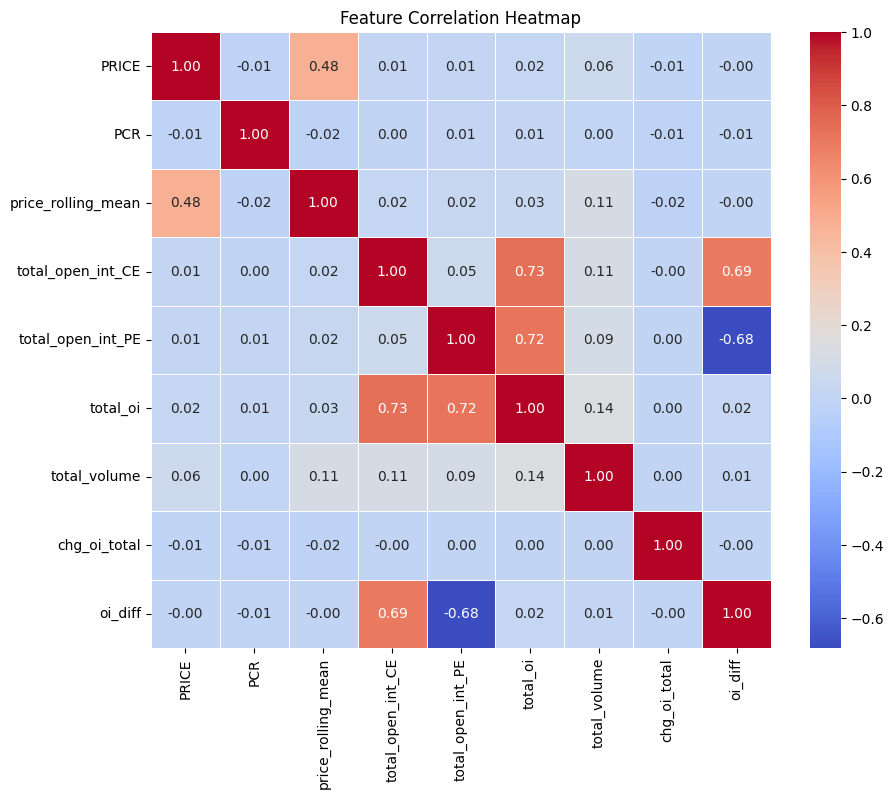

In [99]:
# Correlation heatmap
corr_df = model_df[['PRICE', 'PCR', 'price_rolling_mean', 'total_open_int_CE', 'total_open_int_PE', 'total_oi', 'total_volume', 'chg_oi_total', 'oi_diff']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


## 10. Model And Final Dataset Export

In [100]:
import joblib
joblib.dump(xgb_model, 'xgbost_model.joblib')

['xgbost_model.joblib']

In [101]:
agg_pivot.to_csv('modified_datasset.csv', index = False)

## 11- Initial Testing

In [113]:
def test_model(sample_input):    
    if isinstance(sample_input, dict):
        sample_input = pd.DataFrame([sample_input])
    
    input_data = sample_input[feature_cols]
    
    input_scaled = scaler.fit_transform(input_data)
    
    pred_price = xgb_model.predict(input_scaled)
    
    pred_direction = (pred_price > input_data['PRICE']).astype(int)
    
    return {
        "predicted_price": pred_price,
        "predicted_direction": pred_direction
    }
    


In [114]:
sample = {
    'PCR': 39.444,
    'PRICE':9850.38,
    'price_rolling_mean': 1082.381,
    'total_open_int_CE': 540,
    'total_open_int_PE': 21300,
    'total_contracts_CE': 12,
    'total_contracts_PE': -205263.08,
    'total_oi': 21840,
    'total_volume': -205251,
    'chg_oi_total': 9285,
    'oi_diff': -20760
}

result = test_model(sample)
print(result)

{'predicted_price': array([868.1666], dtype=float32), 'predicted_direction': 0    0
Name: PRICE, dtype: int64}
